<div style="background-color: #ffffff; color: #000000; padding: 10px;">
<div style="display: flex; justify-content: space-between; align-items: center; background-color: #ffffff; color: #000000; padding: 10px;">
    <img src="../00_aisc/img/logo_aisc_150dpi.png" height="80" style="margin-right: auto;" alt="Logo of the AI Service Center Berlin-Brandenburg.">
    <img src="../00_aisc/img/logo_bmftr_de.png" height="150" style="margin-left: auto;" alt="Logo of the German Federal Ministry of Research, Technology and Space: Gefördert vom Bundesministerium für Forschung, Technologie und Raumfahrt.">
</div>
<h1> RAG III
</div>

# 04 — Generation Evaluation

Dieses Notebook evaluiert die **Generierungsqualität** unseres RAG-Systems:

1. Ground-Truth-Daten laden und Kontexte aus Qdrant abrufen
2. Antworten generieren (RAG-Pipeline)
3. **Answer Correctness** messen — Ist die Antwort inhaltlich korrekt?
4. **Faithfulness** messen — Ist die Antwort durch die Kontexte belegt?
5. Ergebnisse inspizieren und Schwachstellen identifizieren
6. Experiment: Was passiert, wenn der System-Prompt geändert wird?

> **Wichtig:** Eine Antwort kann **faithful** sein (alle Aussagen sind im Kontext belegt)
> und trotzdem **falsch** (die Kontexte enthielten nicht die richtige Information).
> Answer Correctness und Faithfulness messen daher unterschiedliche Fehlerarten.

**Voraussetzung:** `w3_02_ingestion.ipynb` muss erfolgreich durchgelaufen sein (Qdrant-Collection befüllt).

In [1]:
# Gemeinsame Konfiguration laden (Pfade, Modellnamen, Qdrant-Einstellungen)
from config import *

# --- Imports ---
import numpy as np
import json
import os
import asyncio
import pandas as pd
import matplotlib.pyplot as plt
from typing import List
from openai import AsyncOpenAI
from litellm import embedding, completion, acompletion
from qdrant_client import QdrantClient
from ragas.llms import llm_factory
from ragas.embeddings.litellm_provider import LiteLLMEmbeddings
from ragas.metrics.collections import AnswerCorrectness, Faithfulness
from ragas.metrics.collections.answer_correctness.metric import StatementGeneratorInput, StatementGeneratorOutput
from ragas.metrics.collections.faithfulness.util import StatementGeneratorInput, StatementGeneratorOutput
from IPython.display import Markdown, display

# --- Toggle: auf True setzen, um gespeicherte Ergebnisse zu laden ---
LOAD_FROM_CACHE = True

=== Workshop-Konfiguration ===
  PDF:             IT_Grundschutz_Kompendium_Edition2023.pdf | exists: True
  Datensatz:       40_einfach (GSKI_Fragen-Antworten-Fundstellen_40_Einfach.csv, sep=",") | exists: True
  Embedding:       openai/octen-embedding-8b (max_chars=None)
  RAG-Modell:      openai/gpt-oss-120b
  Evaluator:       gpt-oss-120b
  API Base URL:    https://api.aisc.hpi.de/
  API Key gesetzt: True
  Qdrant:          localhost:6333
  Chunking-Modus:  json_structured_sections
  Collection:      grundschutz_chunks_json_structured_sections__octen-embedding-8b
  Chunking:        MAX_CHUNK=1200, OVERLAP=200, TOP_K=5


## 1) Ground Truth laden und Kontexte abrufen

Wir laden den Datensatz wie in Notebook 03 und rufen die Kontexte erneut aus Qdrant ab.

In [2]:
def _truncate(text: str, max_chars: int = 500) -> str:
    """Truncate text to max_chars, breaking at the last space if possible.

    Args:
        text: Input text to truncate.
        max_chars: Maximum number of characters.

    Returns:
        Truncated text.
    """
    if len(text) <= max_chars:
        return text
    truncated = text[:max_chars]
    last_space = truncated.rfind(" ")
    if last_space > max_chars // 2:
        truncated = truncated[:last_space]
    return truncated


def embed_texts_litellm(texts: List[str], model: str = EMBED_MODEL_NAME, batch_size: int = EMBED_BATCH_SIZE, max_chars: int = EMBED_MAX_CHARS) -> List[List[float]]:
    """Embed a list of texts using the HPI API via LiteLLM.

    Args:
        texts: List of text strings to embed.
        model: Model identifier in LiteLLM format.
        batch_size: Number of texts to embed per API call.
        max_chars: Truncate texts to this many characters before embedding (None = no limit).

    Returns:
        List of embedding vectors (each a list of floats).
    """
    if max_chars:
        texts = [_truncate(t, max_chars) for t in texts]
    vectors = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]                # Aktuellen Batch aus der Textliste schneiden
        resp = embedding(model=model, input=batch, api_base=API_BASE_URL, encoding_format='float')  # API-Aufruf: Texte → Vektoren
        for item in resp.data:
            # LiteLLM gibt Embeddings je nach Version als Objekt oder Dict zurück
            vec = item.embedding if hasattr(item, 'embedding') else item.get('embedding')
            if vec is None:
                raise RuntimeError('Embedding response ohne Vektor erhalten.')
            vectors.append(vec)
        print(f'  Embedded {len(vectors)}/{len(texts)}', end='\r')  # Fortschrittsanzeige
    print()
    return vectors

# CSV laden
df = pd.read_csv(CSV_PATH, sep=CSV_SEP)
questions = df['Frage'].tolist()       # Alle Fragen als Liste von Strings
references = df['Antwort'].tolist()    # Zugehörige Referenzantworten
print(f'{len(df)} Fragen geladen.')

# Verbindung zu Qdrant herstellen (Collection wurde in Notebook 02 befüllt)
qdrant = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)
info = qdrant.get_collection(COLLECTION_NAME)
print(f'Qdrant-Collection "{COLLECTION_NAME}": {info.points_count} Vektoren\n')

# Fragen in Vektoren umwandeln (gleicher Embedding-Raum wie die Chunks)
print(f'Embedding {len(questions)} Fragen...')
question_vectors = embed_texts_litellm(questions)

# Für jede Frage die TOP_K ähnlichsten Chunks aus Qdrant per Cosine-Similarity abrufen
print(f'Retrieving top-{TOP_K} Kontexte pro Frage...')
retrieved_contexts = []
for q_vec in question_vectors:
    response = qdrant.query_points(
        collection_name=COLLECTION_NAME,
        query=q_vec,                    # Frage-Vektor als Suchanfrage
        limit=TOP_K,                    # Anzahl der Treffer
        with_payload=True,              # Chunk-Text im Ergebnis mitliefern
    )
    # Nur den Textinhalt der Treffer extrahieren (aus dem Payload)
    retrieved_contexts.append([hit.payload['text'] for hit in response.points])

print(f'Fertig. {len(retrieved_contexts)} Fragen mit je {TOP_K} Kontexten.')

40 Fragen geladen.
Qdrant-Collection "grundschutz_chunks_json_structured_sections__octen-embedding-8b": 4080 Vektoren

Embedding 40 Fragen...
  Embedded 40/40
Retrieving top-5 Kontexte pro Frage...
Fertig. 40 Fragen mit je 5 Kontexten.


## 2) Antworten generieren (RAG Generation)

In [3]:
# Das LLM soll **nur** die Informationen aus dem Kontext verwenden.
SYSTEM_PROMPT = (
    'Du bist ein RAG-Assistent für IT-Grundschutz. '
    'Beantworte die Frage nur auf Basis des bereitgestellten Kontexts. '
    'Wenn die Information im Kontext nicht enthalten ist, sage das klar.'
)

async def generate_rag_answer(question: str, contexts: List[str], system_prompt: str = SYSTEM_PROMPT) -> str:
    """Generate an answer to a question using retrieved contexts via LiteLLM.

    Uses 'async def' so that multiple calls can run concurrently via
    asyncio.gather() — instead of waiting for each API call sequentially,
    all requests are sent at once and processed in parallel.

    The 'await' keyword pauses this function at the API call, allowing
    other concurrent tasks to proceed while waiting for the response.

    Args:
        question: The user's question.
        contexts: List of retrieved text chunks to use as context.
        system_prompt: System prompt for the LLM.

    Returns:
        The generated answer as a string.
    """
    # Kontexte nummeriert zusammenfügen
    context_block = '\n\n'.join(
        f'[Quelle {i+1}]\n{ctx}' for i, ctx in enumerate(contexts)
    )

    # 'await' pausiert hier, bis die API antwortet — andere Tasks laufen weiter
    resp = await acompletion(
        model=RAG_MODEL_NAME,
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': f'Frage:\n{question}\n\nKontext:\n{context_block}'},
        ],
        api_base=API_BASE_URL,
        api_key=os.getenv('OPENAI_API_KEY'),
        temperature=0.2,
        max_tokens=10000,
    )
    return resp.choices[0].message.content

# ---------------------------------------------------------------------------
# Eigene Frage an das RAG-System stellen
# Zeigt den kompletten RAG-Ablauf: Frage → Embedding → Retrieval → Generierung
# ---------------------------------------------------------------------------
CUSTOM_QUESTION = "Was ist der IT Grundschutz des BSI?" # Was passiert bei der Frage "Wofür steht BSI?" ?

# Schritt 1: Frage in einen Vektor umwandeln (gleicher Embedding-Raum wie die Chunks)
# embed_texts_litellm erwartet eine Liste und gibt eine Liste zurück — [0] extrahiert den einzelnen Vektor
custom_question_vector = embed_texts_litellm([CUSTOM_QUESTION])[0]

# Schritt 2: Die TOP_K ähnlichsten Chunks aus Qdrant per Cosine-Similarity abrufen
custom_response = qdrant.query_points(
    collection_name=COLLECTION_NAME,
    query=custom_question_vector,
    limit=TOP_K,
    with_payload=True,
)
custom_contexts = [hit.payload['text'] for hit in custom_response.points]  # Nur Texte extrahieren

# Schritt 3: Antwort generieren
# 'await' ist nötig, da generate_rag_answer eine async-Funktion ist —
# ohne await wird die Funktion nicht ausgeführt, sondern nur ein Coroutine-Objekt erzeugt
answer_to_custom_question = await generate_rag_answer(CUSTOM_QUESTION, custom_contexts)

# Schritt 4: Antwort als formatiertes Markdown anzeigen
print()
print(f'Frage: {CUSTOM_QUESTION}')
print('=' * 100)
display(Markdown(answer_to_custom_question))
print('=' * 100)

  Embedded 1/1

Frage: Was ist der IT Grundschutz des BSI?


Der IT‑Grundschutz ist ein vom Bundesamt für Sicherheit in der Informationstechnik (BSI) bereitgestelltes Konzept, das standardisierte Sicherheitsanforderungen für typische Geschäftsprozesse, Anwendungen, IT‑Systeme, Kommunikationsverbindungen, Gebäude und Räume definiert.  

Im IT‑Grundschutz‑Kompendium werden diese Anforderungen in **Bausteinen** beschrieben, die jeweils die zu schützende Komponente, mögliche Gefährdungen und konkrete Maßnahmen enthalten. Ziel ist es, durch eine Kombination aus organisatorischen, personellen, infrastrukturellen und technischen Sicherheitsmaßnahmen ein dem Schutzbedarf entsprechendes Sicherheitsniveau zu erreichen.  

Der Ansatz ist **ganzheitlich** und nutzt ein **Baukastenprinzip**, sodass Institutionen sowohl eine Basis‑Absicherung (breite Erstabsicherung aller Geschäftsprozesse) als auch weiterführende, höhere Sicherheitsniveaus umsetzen können. Der IT‑Grundschutz bildet damit den Stand der Technik zum jeweiligen Veröffentlichungszeitpunkt ab und dient als Basis für den Schutz institutioneller Informationen.

Für jede Frage generieren wir nun eine Antwort auf Basis der abgerufenen Kontexte.
Das LLM soll **nur** die Informationen aus dem Kontext verwenden.

> **Laufzeit:** Bei 40 Fragen dauert die Generierung ca. 5–10 Minuten
> (ein LLM-Aufruf pro Frage, Reasoning-Modell). Daher laden wir wenn möglich aus dem Cache.

In [4]:
# --- Antworten generieren oder aus Cache laden ---
RESPONSE_CACHE = CACHE_DIR / f'generation_responses_top{TOP_K}.json'

if LOAD_FROM_CACHE and RESPONSE_CACHE.exists():
    with open(RESPONSE_CACHE, 'r') as f:
        responses = json.load(f)
    print(f'Antworten aus Cache geladen: {RESPONSE_CACHE.name} ({len(responses)} Antworten)')
else:
    # Antworten für alle Fragen parallel generieren:
    # asyncio.gather() startet alle API-Aufrufe gleichzeitig statt nacheinander.
    print(f'Generiere Antworten für {len(questions)} Fragen (Modell: {RAG_MODEL_NAME}, parallel)...')
    tasks = [generate_rag_answer(q, ctxs) for q, ctxs in zip(questions, retrieved_contexts)]
    responses = list(await asyncio.gather(*tasks))

    # Antworten speichern
    with open(RESPONSE_CACHE, 'w') as f:
        json.dump(responses, f, ensure_ascii=False)
    print(f'Antworten gespeichert: {RESPONSE_CACHE.name}')

# Beispiel: Frage, Referenzantwort und generierte Antwort
print()
question_number = 3
print(f'Frage: {questions[question_number]}')
print('=' * 50, "reference answer", "=" * 50)
display(Markdown(references[question_number]))
print('=' * 50, "generated answer", "=" * 50)
display(Markdown(responses[question_number]))

Antworten aus Cache geladen: generation_responses_top5.json (40 Antworten)

Frage: Welche Sicherheitsanforderungen gelten für Datei-Uploads und -Downloads über einen Webserver?
================================================== reference answer ==================================================


Alle mithilfe des Webservers veröffentlichten Dateien müssen vorher auf Schadsoftware geprüft werden. Es muss eine Maximalgröße für Datei-Uploads festgelegt und ausreichend Speicherplatz reserviert sein.

================================================== generated answer ==================================================


**Sicherheitsanforderungen für Datei‑Uploads und –Downloads über einen Webserver (nach IT‑Grundschutz)**  

| Anforderung | Beschreibung (nach den angegebenen Quellen) |
|-------------|---------------------------------------------|
| **Prüfung auf Schadsoftware** | Alle über den Webserver veröffentlichten bzw. hochgeladenen Dateien **müssen** vor der Bereitstellung auf Schadprogramme (Malware, Viren, etc.) geprüft werden. <br>*Quelle 1: APP.3.2.A3* |
| **Maximale Dateigröße** | Für Upload‑ und Download‑Operationen **muss** eine maximale Dateigröße definiert sein. <br>*Quelle 1: APP.3.2.A3* |
| **Reservierung von Speicherplatz** | Der IT‑Betrieb muss sicherstellen, dass für die zulässige Maximalgröße ausreichend Speicherplatz bereitgestellt ist. <br>*Quelle 1: APP.3.2.A3* |
| **Einschränkung der Upload‑Funktion** | Die Upload‑Funktion soll **so weit wie möglich** eingeschränkt werden: <br>• zulässige Dateigröße <br>• zulässige Dateitypen <br>• zulässige Speicherorte <br>• zulässige Clients (Benutzer/ Systeme) <br>*Quelle 2: APP.3.1.A4* |
| **Restriktive Zugriffs‑ und Ausführungsrechte** | Für hochgeladene Dateien und die Verzeichnisse, in denen sie abgelegt werden, **müssen** restriktive Rechte gesetzt werden (z. B. kein Ausführungsrecht für nicht vertrauenswürdige Dateien). <br>*Quelle 2: APP.3.1.A4* |
| **Kontrollierter Ablageort** | Benutzer dürfen Dateien **nur** im vorgegebenen, erlaubten Verzeichnis speichern. Der Ablageort darf vom Benutzer nicht beeinflusst werden können (z. B. keine Pfad‑Manipulation). <br>*Quelle 2: APP.3.1.A4* <br>*Quelle 3: CON.10.A5* |
| **Konfigurierbarkeit der Upload‑Funktion** | Die Webanwendung muss Funktionen bereitstellen, mit denen die Upload‑Parameter (Größe, Typen, Pfade, erlaubte Clients) **während des Betriebs** konfiguriert werden können. <br>*Quelle 3: CON.10.A5* |
| **Beschränkung auf definierten Verzeichnisbaum** | Der Webserver **muss** so konfiguriert sein, dass Anwendungen nur auf einen definierten Verzeichnisbaum (WWW‑Wurzelverzeichnis) zugreifen können. Dateien außerhalb dieses Baums dürfen nicht ausgeliefert werden. <br>*Quelle 5: APP.3.2.A2* |
| **Verhinderung von Verzeichnis‑Listing** | Alle nicht benötigten Funktionen, die das Auflisten von Verzeichnissen ermöglichen, **müssen** deaktiviert werden. <br>*Quelle 5: APP.3.2.A2* |
| **Schutz vertraulicher Daten** | Vertrauliche Dateien **dürfen nicht** in öffentlichen Verzeichnissen des Webservers liegen und müssen vor unberechtigtem Zugriff geschützt werden. Regelmäßige Kontrollen sind erforderlich. <br>*Quelle 5: APP.3.2.A2* |
| **Allgemeine Integrität** | Durch die Kombination der oben genannten Maßnahmen wird sichergestellt, dass hochgeladene bzw. heruntergeladene Dateien nicht unautorisiert verändert, ausgeführt oder missbraucht werden können. |

### Zusammengefasst
- **Scanning** aller Dateien auf Schadsoftware.  
- **Maximale Größe** festlegen und **Speicherplatz** reservieren.  
- **Erlaubte Dateitypen, -größen, -orte** und **Clients** streng definieren.  
- **Zugriffs‑ und Ausführungsrechte** für Upload‑Verzeichnisse restriktiv setzen.  
- **Pfad‑Kontrolle**: Benutzer können den Zielpfad nicht beeinflussen; nur vordefinierte Pfade zulässig.  
- **Konfigurierbarkeit** der Upload‑Parameter im laufenden Betrieb.  
- **Webserver‑Konfiguration**: Zugriff nur auf das WWW‑Wurzelverzeichnis, kein Directory‑Listing, vertrauliche Daten nicht in öffentlichen Bereichen.  

Nur wenn all diese Punkte umgesetzt werden, erfüllen Datei‑Uploads und –Downloads die Sicherheitsanforderungen des IT‑Grundschutzes.

## 3) Answer Correctness

**Answer Correctness** misst, ob die generierte Antwort **inhaltlich korrekt** ist —
verglichen mit der Referenzantwort aus dem Ground-Truth-Datensatz.

Die Metrik kombiniert zwei Komponenten (gewichtet 75/25):
$$ AC = 0.75 \cdot F1 + 0.25 \cdot CS $$

#### 1. F1 score (75%)
Das Evaluator-LLM zerlegt sowohl die generierte Antwort als auch die Referenzantwort
in atomare Aussagen (Claims) und klassifiziert sie:

- **TP (True Positive)** — Aussage in Antwort UND in Referenz enthalten
- **FP (False Positive)** — Aussage in Antwort, aber NICHT in Referenz (falsch/extra)
- **FN (False Negative)** — Aussage in Referenz, aber NICHT in Antwort (fehlend)

$$F1 = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

#### 2. Semantic Similarity CS (25%)
Embedding-basierte Cosine Similarity zwischen der gesamten Antwort und der gesamten Referenz.


In [5]:
# Evaluator-LLM und Embeddings einrichten
evaluator_client = AsyncOpenAI(
    api_key=os.getenv('OPENAI_API_KEY'),
    base_url=API_BASE_URL,
)
evaluator_llm = llm_factory(
    EVALUATOR_MODEL_NAME,
    client=evaluator_client,
    max_tokens=65536,              # Sehr hoch, da Reasoning-Modell ~20-30k Tokens für internes Denken braucht
)

# Embeddings für die Semantic-Similarity-Komponente von Answer Correctness
evaluator_embeddings = LiteLLMEmbeddings(
    model=EMBED_MODEL_NAME,
    api_key=os.getenv('OPENAI_API_KEY'),
    api_base=API_BASE_URL,
    encoding_format='float',
)

# Answer Correctness initialisieren (braucht LLM + Embeddings)
answer_correctness = AnswerCorrectness(llm=evaluator_llm, embeddings=evaluator_embeddings)

# --- Demo: Answer Correctness für eine einzelne Frage berechnen ---
# Zeigt den Score für das Beispiel aus der Erklärung oben 
demo_question = questions[question_number]
demo_reference = references[question_number]
demo_response = responses[question_number]

print(f'Frage:     {demo_question}')
print(f'Referenz:  {demo_reference[:100]}...')
print(f'Antwort:   {demo_response[:100]}...')
print()

# Einzelne Frage evaluieren (abatch_score erwartet eine Liste)
demo_result = await answer_correctness.abatch_score([{
    'user_input': demo_question,
    'response': demo_response,
    'reference': demo_reference,
}])

print(f'Answer Correctness Score: {float(demo_result[0].value):.4f}')

Frage:     Welche Sicherheitsanforderungen gelten für Datei-Uploads und -Downloads über einen Webserver?
Referenz:  Alle mithilfe des Webservers veröffentlichten Dateien müssen vorher auf Schadsoftware geprüft werden...
Antwort:   **Sicherheitsanforderungen für Datei‑Uploads und –Downloads über einen Webserver (nach IT‑Grundschut...

Answer Correctness Score: 0.5297


- Was passiert wenn wir die obrige Codezelle erneut ausführen? <br>
- Ändert sich der Wert des Answer Correctness Score? <br>
- Falls ja, warum? 

In [6]:
# ---------------------------------------------------------------------------
# Blick hinter die Kulissen: Wie zerlegt das Evaluator-LLM Texte in Claims?
# ---------------------------------------------------------------------------
# RAGAS gibt über die API nur den finalen Score zurück, nicht die intern
# erzeugten Claims. Hier rufen wir den gleichen Prompts manuell auf, die
# AnswerCorrectness intern für Claim-Zerlegung und Klassifikation verwendet.
#
# WICHTIG: Da jeder LLM-Aufruf leicht unterschiedliche Ergebnisse liefert
# (auch bei temperature ≈ 0), sind die hier angezeigten Claims NICHT exakt
# dieselben, die in der Bewertung oben verwendet wurden — sie zeigen aber
# den gleichen Mechanismus und sind qualitativ vergleichbar.
# ---------------------------------------------------------------------------

# --- Schritt 1: Claims aus beiden Texten extrahieren ---
print('Claims aus der Referenzantwort:')
ref_prompt = answer_correctness.statement_generator_prompt.to_string(
    StatementGeneratorInput(question=demo_question, answer=demo_reference)
)
ref_claims = await evaluator_llm.agenerate(ref_prompt, StatementGeneratorOutput)
for i, stmt in enumerate(ref_claims.statements):
    print(f'  {i+1}. {stmt}')

print()

print('Claims aus der generierten Antwort:')
resp_prompt = answer_correctness.statement_generator_prompt.to_string(
    StatementGeneratorInput(question=demo_question, answer=demo_response)
)
resp_claims = await evaluator_llm.agenerate(resp_prompt, StatementGeneratorOutput)
for i, stmt in enumerate(resp_claims.statements):
    print(f'  {i+1}. {stmt}')

print(f'\n→ Referenz: {len(ref_claims.statements)} Claims, Antwort: {len(resp_claims.statements)} Claims')

# --- Schritt 2: TP/FP/FN Klassifikation ---
classification = await answer_correctness._classify_statements(
    demo_question, resp_claims.statements, ref_claims.statements
)
tp, fp, fn = len(classification.TP), len(classification.FP), len(classification.FN)
f1 = answer_correctness._compute_f1_score(classification)

print(f'\nKlassifikation: TP={tp}, FP={fp}, FN={fn}')
print(f'F1-Score (Factual):  {f1:.3f}')

# TP, FP, FN im Detail anzeigen
for label, items in [('TP', classification.TP), ('FP', classification.FP), ('FN', classification.FN)]:
    if items:
        print(f'\n  {label}:')
        for item in items:
            print(f'    • {item.statement}')
            print(f'      Grund: {item.reason}')

# --- Schritt 3: Semantic Similarity ---
ref_emb = embed_texts_litellm([demo_reference])[0]
resp_emb = embed_texts_litellm([demo_response])[0]
cos_sim = np.dot(ref_emb, resp_emb) / (np.linalg.norm(ref_emb) * np.linalg.norm(resp_emb))

print(f'\nSemantic Similarity (Cosine): {cos_sim:.3f}')

# --- Schritt 4: Gewichteter Gesamtscore ---
final = 0.75 * f1 + 0.25 * cos_sim
print(f'\nAnswer Correctness = 0.75 · {f1:.3f} + 0.25 · {cos_sim:.3f} = {final:.3f}')

Claims aus der Referenzantwort:
  1. Alle Dateien, die mithilfe des Webservers veröffentlicht werden, müssen vorher auf Schadsoftware geprüft werden.
  2. Eine Maximalgröße für Datei-Uploads muss festgelegt werden.
  3. Ausreichender Speicherplatz für Datei-Uploads muss reserviert werden.

Claims aus der generierten Antwort:
  1. Alle über den Webserver veröffentlichten oder hochgeladenen Dateien müssen vor der Bereitstellung auf Schadprogramme wie Malware und Viren geprüft werden.
  2. Für Upload- und Download-Operationen muss eine maximale Dateigröße definiert sein.
  3. Der IT-Betrieb muss sicherstellen, dass für die zulässige Maximalgröße ausreichend Speicherplatz bereitgestellt wird.
  4. Die Upload-Funktion soll so weit wie möglich eingeschränkt werden.
  5. Zulässige Dateigröße muss definiert werden.
  6. Zulässige Dateitypen müssen definiert werden.
  7. Zulässige Speicherorte müssen definiert werden.
  8. Zulässige Clients (Benutzer oder Systeme) müssen definiert werden.
  9. 

- Was passiert wenn wir die obrige Codezelle erneut ausführen? <br>
- Ändert sich die Anzahl der Claims? 

### Beispiel

**Frage:** *„Welche Sicherheitsanforderungen gelten für Datei-Uploads und -Downloads über einen Webserver?"*

**Referenzantwort (kurz, 2 Sätze):**
> *„Alle mithilfe des Webservers veröffentlichten Dateien müssen vorher auf Schadsoftware
> geprüft werden. Es muss eine Maximalgröße für Datei-Uploads festgelegt und ausreichend
> Speicherplatz reserviert sein."*

**Generierte Antwort (ausführlich, mit Quellenverweisen und Tabelle):**
> *„Prüfung auf Schadprogramme — Alle über den Webserver veröffentlichten Dateien müssen
> vor der Bereitstellung auf Schadsoftware geprüft werden (APP.3.2.A3).
> Maximale Dateigröße festlegen — Für Upload-Vorgänge muss eine maximale Dateigröße definiert
> werden (APP.3.2.A3, APP.3.1.A4).
> Speicherplatz reservieren — ausreichend Speicherplatz für erwartete Uploads bereitstellen.
> Einschränkung der Upload-Funktion — zulässige Dateitypen, Speicherorte und Clients festlegen.
> Restriktive Zugriffs- und Ausführungsrechte für Upload-Verzeichnisse.
> Kontrollierter Ablageort — Benutzer dürfen nur in vorab definierten Verzeichnissen speichern.
> ..."* (gekürzt)

**Schritt 1 — Claim-Zerlegung** (durch das Evaluator-LLM):

Das Evaluator-LLM zerlegt die **Referenz in 3 Claims** und die **generierte Antwort in 22 Claims**:

| # | Claims aus Referenz (3) | Claims aus Antwort (Auswahl von 22) |
|---|---|---|
| 1 | Alle veröffentlichten Dateien müssen auf Schadsoftware geprüft werden | Dateien müssen vor Bereitstellung auf Schadsoftware geprüft werden |
| 2 | Eine Maximalgröße für Datei-Uploads muss festgelegt werden | Für Uploads muss eine maximale Dateigröße definiert werden |
| 3 | Ausreichend Speicherplatz muss reserviert werden | Ausreichend Speicherplatz für erwartete Uploads bereitstellen |
| 4 | | Zulässige Dateigrößen müssen festgelegt werden *(Duplikat von #2)* |
| 5 | | Vorab-Prüfung auf Schadsoftware muss durchgeführt werden *(Duplikat von #1)* |
| 6 | | Die Upload-Funktion soll eingeschränkt werden |
| 7 | | Zulässige Dateitypen müssen festgelegt werden |
| 8 | | Restriktive Rechte für Upload-Verzeichnisse |
| ... | | *(14 weitere Claims zu Speicherorten, Pfad-Manipulation, Verzeichnis-Listing, etc.)* |

**Schritt 2 — Klassifikation:**

| Typ | Anzahl | Bedeutung |
|---|---|---|
| **TP** | 5 | 5 Antwort-Claims sind durch die Referenz belegt |
| **FP** | 17 | 17 Antwort-Claims stehen nicht in der Referenz |
| **FN** | 0 | Keine Referenz-Claims fehlen in der Antwort |

→ F1 = 2·5 / (2·5 + 17 + 0) = **0.37**

**Warum 5 TP bei nur 3 Referenz-Claims?** Die generierte Antwort wiederholt Fakten in
unterschiedlicher Formulierung (z.B. „Maximale Dateigröße definiert werden" und „Zulässige
Dateigrößen festlegen"). Beide werden als TP gewertet, weil sie denselben Referenz-Claim
matchen. TP kann also **größer** sein als die Anzahl der Referenz-Claims — Duplikate zählen.

**Schritt 3 — Semantic Similarity:**

Cosine Similarity der Embeddings von Antwort und Referenz: **0.85**

**Schritt 4 — Gewichteter Gesamtscore:**

Answer Correctness = 0.75 · 0.37 + 0.25 · 0.85 = **0.49**

> **Wichtig:** Die generierte Antwort enthält **alle** Fakten der Referenz (FN=0)
> und ist fachlich ausgezeichnet — aber der Score ist nur 0.49, weil 17 von 22 Claims
> als FP gewertet werden. Answer Correctness misst die **Übereinstimmung mit der Referenz**,
> nicht die fachliche Qualität. Je kürzer die Referenz und je ausführlicher die Antwort, desto niedriger der Score.

> **Wichtig:** Die Identifizierung der claims durch das Evaluator-LLM ist **nicht** deterministisch, und kann sich pro Aufruf ändern (und somit auch die Answer Correctness)!

In [7]:
# Nun evaluieren wir den gesamtes Datensatz

# --- Answer Correctness evaluieren oder aus Cache laden ---
AC_CACHE = CACHE_DIR / f'answer_correctness_top{TOP_K}.json'

if LOAD_FROM_CACHE and AC_CACHE.exists():
    with open(AC_CACHE, 'r') as f:
        ac_scores = json.load(f)
    print(f'Answer Correctness aus Cache geladen: {AC_CACHE.name}')
else:
    # Eingaben aufbauen — Answer Correctness braucht: user_input, response, reference
    ac_inputs = [
        {
            'user_input': questions[i],
            'response': responses[i],
            'reference': references[i],
        }
        for i in range(len(questions))
    ]

    # Parallele Evaluation
    print(f'Evaluiere Answer Correctness für {len(questions)} Fragen (parallel)...\n')
    ac_results = await answer_correctness.abatch_score(ac_inputs)
    ac_scores = [float(r.value) for r in ac_results]

    # Ergebnisse speichern
    with open(AC_CACHE, 'w') as f:
        json.dump(ac_scores, f)
    print(f'Ergebnisse gespeichert: {AC_CACHE.name}')

print(f'Answer Correctness (Durchschnitt): {sum(ac_scores) / len(ac_scores):.2f}')

# Per-Frage Scores anzeigen
ac_df = pd.DataFrame({
    'user_input': questions,
    'reference': references,
    'response': responses,
    'answer_correctness': ac_scores,
})
ac_df[['user_input', 'answer_correctness']].head(5)

Answer Correctness aus Cache geladen: answer_correctness_top5.json
Answer Correctness (Durchschnitt): 0.63


,user_input,answer_correctness
0,Was ist der Unterschied zwischen Prozess- und ...,0.534007
1,Welche grundlegenden Sicherheitsmaßnahmen müss...,0.675470
2,Wie müssen Webserver-Dateien geschützt werden?,0.868164
3,Welche Sicherheitsanforderungen gelten für Dat...,0.480985
4,Welche Ereignisse müssen auf einem Webserver p...,0.930576


Saved: /Users/david.goll/Documents/projects/workshop-ragV2/notebooks/figures/04_generation_evaluation/answer_correctness_hist__octen-embedding-8b__json_structured_sections__40_einfach__top5__gpt-oss-120b.png


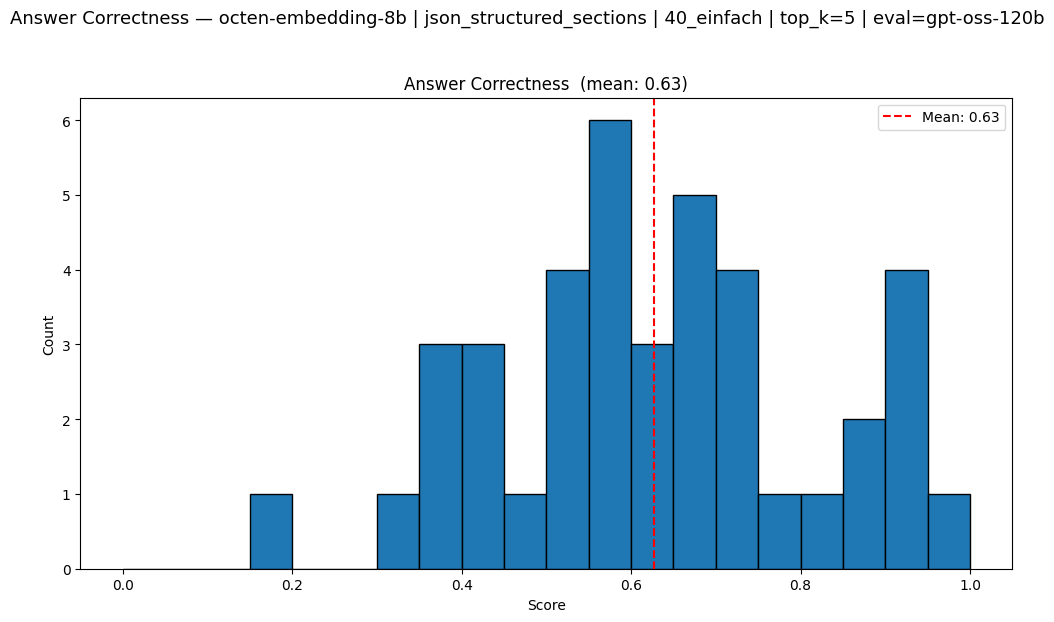

In [8]:
# Histogramm der Answer Correctness Scores
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(ac_df['answer_correctness'], bins=20, edgecolor='black', range=(0,1))
ax.set_xlabel('Score')
ax.set_ylabel('Count')
mean_score = ac_df['answer_correctness'].mean()
ax.set_title(f'Answer Correctness  (mean: {mean_score:.2})')
ax.axvline(mean_score, color='red', linestyle='--', label=f'Mean: {mean_score:.2f}')
ax.legend()

fig.suptitle(
    f'Answer Correctness — {EMBED_SHORT} | {CHUNKING_MODE} | {DATASET} | top_k={TOP_K} | eval={EVALUATOR_SHORT}',
    fontsize=13, y=1.03,
)
plt.tight_layout()

# Figur speichern
fig_dir = FIGURES_DIR / '04_generation_evaluation'
fig_dir.mkdir(parents=True, exist_ok=True)
fig_path = fig_dir / f'answer_correctness_hist__{EMBED_SHORT}__{CHUNKING_MODE}__{DATASET}__top{TOP_K}__{EVALUATOR_SHORT}.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved: {fig_path}')

plt.show()

In [9]:
# Beste und schlechteste Frage (Answer Correctness) vergleichen
for label, row in [('Schlechteste', ac_df.nsmallest(1, 'answer_correctness').iloc[0]),
                    ('Beste', ac_df.nlargest(1, 'answer_correctness').iloc[0])]:
    print(f'=== {label} Frage (Score: {row["answer_correctness"]:.3f}) ===')
    print(f'Frage: {row["user_input"]}')
    display(Markdown(f'**Referenzantwort:**\n\n{row["reference"]}'))
    display(Markdown(f'**Generierte Antwort:**\n\n{row["response"]}'))
    print()

=== Schlechteste Frage (Score: 0.182) ===
Frage: Welche Vertretungsregelungen müssen im Sicherheitsmanagement existieren?


**Referenzantwort:**

Für alle wichtigen Informationssicherheitsfunktionen muss es wirksame Vertretungen geben. Die Kommunikationswege müssen geplant, dokumentiert, eingerichtet und allen bekannt sein. Es muss klar sein, wer welche Informationen erhält und wer bei welchen Maßnahmen informiert werden muss. Außerdem muss regelmäßig überprüft werden, ob die Organisationsstruktur der Informationssicherheit noch passend ist oder angepasst werden muss.

**Generierte Antwort:**

**Im Sicherheitsmanagement müssen Vertretungsregelungen für alle relevanten Bereiche existieren.**  
Die Vorgaben aus den IT‑Grundschutz‑Modulen lassen sich wie folgt zusammenfassen:

| Bereich / Anforderung | Was die Vertretungsregelung enthalten muss |
|-----------------------|--------------------------------------------|
| **Allgemeine Geschäftsprozesse (ORP.2.A3)** | • Für **alle wesentlichen Geschäftsprozesse und Aufgaben** muss eine praktikable Vertretungsregelung vorhanden sein.<br>• Der **Aufgabenumfang** der Vertretung ist **vorab klar zu definieren**.<br>• Die Vertretung muss über das **notwendige Wissen** verfügen – ggf. durch Schulung oder ausreichende Dokumentation des aktuellen Verfahrens‑/Projektstands.<br>• Ist keine kompetente interne Vertretung möglich, muss **frühzeitig geprüft** werden, ob **externes Personal** eingesetzt werden kann. |
| **Administrationsaufgaben (OPS.1.1.2.A2)** | • Für **jede Administrationsaufgabe** muss eine **benannte Vertretung** existieren.<br>• Die Vertretung muss **organisatorisch und technisch** über die erforderlichen **administrativen Berechtigungen** verfügen.<br>• Sie muss die **für die Aufgabe notwendigen Kenntnisse** besitzen.<br>• Die Regelung muss **Mangel‑ und Notfallsituationen** (z. B. Ausfall des Hauptverantwortlichen) berücksichtigen. |
| **Einsatz von Fremd‑ bzw. Sub‑Dienstleistern (ORP.2.A4, OPS.3.2.A18)** | • Auch **externes Personal** (kurz‑ oder langfristig) muss in **Sicherheits‑ und Informationsschutz‑Regelungen** eingewiesen und **überwacht** werden.<br>• Für externes Personal ist **eine eigene Vertretungsregelung** zu etablieren (z. B. wer im Ausfall des Fremdmitarbeiters die Aufgaben übernimmt).<br>• Beim Verlassen des Fremdpersonals sind **Arbeitsergebnisse** und **Zugangsberechtigungen** gemäß interner Vorgaben zu übergeben bzw. zurückzugeben. |
| **Spezifische Ersatzvorkehrungen (INF.11.A11)** | • Für kritische Ressourcen (z. B. **Fahrzeuge** und **Fahrzeugführende**) sollen **Ersatzfahrzeuge** bzw. **Ersatz‑Fahrzeugführende** bereitstehen oder über **Rahmenverträge** mit Fremdinstitutionen gesichert sein. <br>• Diese Ersatz‑ bzw. Vertretungsmaßnahmen sind ebenfalls Teil des Sicherheits‑Managements. |

### Kernelemente, die in jeder Vertretungsregelung enthalten sein müssen
1. **Benennung einer konkreten Vertretung** (Person oder Gruppe).  
2. **Klare Definition des Aufgaben‑/Aufgabenumfangs**, der von der Vertretung übernommen wird.  
3. **Nachweis der erforderlichen Fachkenntnisse** (Schulung, Dokumentation, Erfahrung).  
4. **Zuweisung der notwendigen Berechtigungen** (organisatorisch + technisch).  
5. **Berücksichtigung von Mangel‑ und Notfallsituationen** (z. B. Ausfall, Krankheit).  
6. **Dokumentation und Kommunikation** der Vertretungsregelung innerhalb der Organisation.  
7. **Prüfung und ggf. Einbindung von externem Personal** (Fremd‑/Sub‑Dienstleister) sowie **regelkonforme Übergabe von Arbeitsergebnissen und Zugangsrechten**.  
8. **Spezielle Ersatzvorkehrungen** für besonders kritische Ressourcen (z. B. Fahrzeuge).

Nur wenn all diese Punkte in den jeweiligen Bereichen festgelegt und umgesetzt sind, erfüllt das Sicherheitsmanagement die Anforderungen des IT‑Grundschutzes an Vertretungsregelungen.


=== Beste Frage (Score: 0.978) ===
Frage: Wer trägt die Gesamtverantwortung für Informationssicherheit in der Organisastion?


**Referenzantwort:**

Die Institutionsleitung MUSS die Gesamtverantwortung für Informationssicherheit übernehmen. Sie muss den Sicherheitsprozess initiieren, steuern und kontrollieren sowie Informationssicherheit vorleben.

**Generierte Antwort:**

Die **Institutionsleitung (die Leitung der Organisation)** trägt die Gesamtverantwortung für die Informationssicherheit.  

* Quelle 1 (ISMS.1.A1): „Die Institutionsleitung MUSS die Gesamtverantwortung für Informationssicherheit in der Institution übernehmen.“  

Damit ist die Leitungsebene – also die Institutionsleitung – für das Initiieren, Steuern, Kontrollieren und Vorleben der Informationssicherheit verantwortlich.

## 4) Faithfulness

**Faithfulness** misst, ob die generierte Antwort **durch die abgerufenen Kontexte belegt** ist
(keine Halluzination).

**So funktioniert die Metrik:**
1. Die generierte Antwort wird in einzelne **Aussagen (Claims)** zerlegt
2. Für jede Aussage prüft das Evaluator-LLM: Ist diese Aussage im Kontext belegt? (Verdict: 1=Ja, 0=Nein)
3. Score = Anzahl belegter Aussagen / Gesamtanzahl Aussagen

$$ \text{Faithfulness} = \frac{\text{Anzahl belegter Claims}}{\text{Gesamtanzahl Claims}} $$

### Beispiel

**Frage:** *„Welche Sicherheitsanforderungen gelten für Datei-Uploads und -Downloads über einen Webserver?"*

Das Evaluator-LLM zerlegt die generierte Antwort in **11 Claims** und prüft jeden einzeln
gegen die abgerufenen Kontexte:

| Claim | Verdict | Begründung des Evaluators |
|---|---|---|
| Alle Dateien müssen vor Bereitstellung auf Schadsoftware geprüft werden — **einschließlich hochgeladener Dateien** | ✗ | Kontext nennt nur *veröffentlichte* Dateien, nicht explizit *hochgeladene* |
| Maximale Dateigröße für **Uploads und Downloads** definieren | ✗ | Kontext fordert nur Maximalgröße für *Uploads*, nicht für Downloads |
| Ausreichend Speicherplatz für zulässige Maximalgröße bereitstellen | ✓ | Kontext verlangt ausreichend Speicherplatz für Uploads |
| Upload-Funktion einschränken (Dateigröße, Dateitypen, Speicherorte, Clients) | ✓ | Kontext fordert Einschränkung und nennt alle vier Parameter |
| Restriktive Zugriffs- und Ausführungsrechte für Upload-Verzeichnisse | ✓ | Kontext verlangt restriktive Rechte |
| Benutzer dürfen nur in vorgegebenen Verzeichnissen speichern (keine Pfad-Manipulation) | ✓ | Kontext legt fest, dass Ablageort nicht beeinflusst werden darf |
| Upload-Parameter müssen während des Betriebs konfigurierbar sein | ✓ | Kontext verlangt Konfigurationsfunktionen für Uploads |
| Nur Dateien aus dem WWW-Wurzelverzeichnis ausliefern | ✓ | Kontext schreibt Beschränkung auf WWW-Wurzelverzeichnis vor |
| Verzeichnis-Listing deaktivieren | ✓ | Kontext fordert Deaktivierung nicht benötigter Listing-Funktionen |
| Vertrauliche Dateien nicht in öffentlichen Verzeichnissen + regelmäßige Kontrollen | ✓ | Kontext verlangt Schutz und regelmäßige Überprüfungen |
| **Kombination** der Maßnahmen garantiert Sicherheit | ✗ | Kontext macht keine Aussage über Garantien durch Kombination |

→ **8 von 11 Claims belegt** → Faithfulness = 8/11 = **0.73**

**Warum nicht 1.0?** Die Antwort enthält drei Claims, die leicht über den Kontext hinausgehen:
zwei erweitern korrekte Aussagen um nicht belegte Details (Downloads, hochgeladene Dateien)
und eine ist eine Schlussfolgerung, die der Kontext nicht explizit nennt.
Das sind keine groben Halluzinationen, aber streng genommen nicht durch den Kontext belegt.

**Kernfrage:** Erfindet das LLM Informationen, die nicht im Kontext stehen?

**Benötigte Felder:** `user_input`, `response`, `retrieved_contexts`

In [10]:
# Faithfulness initialisieren (braucht nur LLM, keine Embeddings)
faithfulness = Faithfulness(llm=evaluator_llm)

# ---------------------------------------------------------------------------
# Blick hinter die Kulissen: Wie bewertet Faithfulness einzelne Claims?
# ---------------------------------------------------------------------------
# Faithfulness zerlegt die generierte Antwort in Claims und prüft für jeden:
# "Ist diese Aussage durch die abgerufenen Kontexte belegt?" (Verdict: 1=Ja, 0=Nein)
#
# Score = Anzahl belegter Claims / Gesamtanzahl Claims
#
# WICHTIG: Wie bei Answer Correctness sind dies NICHT exakt die Claims aus
# der Bewertung oben, sondern ein separater LLM-Aufruf mit dem gleichen Prompt.
# ---------------------------------------------------------------------------

# --- Schritt 1: Antwort in atomare Claims zerlegen ---
print(f'Frage: {demo_question}\n')
print('Claims aus der generierten Antwort:')
faith_statements = await faithfulness._create_statements(demo_question, demo_response)

# --- Schritt 2: Jeden Claim gegen die Kontexte prüfen (NLI) ---
context_str = '\n'.join(retrieved_contexts[question_number])
verdicts = await faithfulness._create_verdicts(faith_statements, context_str)

print(f'\n→ {len(faith_statements)} Claims, davon {sum(1 for v in verdicts.statements if v.verdict)} durch Kontexte belegt\n')

# Ergebnisse im Detail anzeigen
for v in verdicts.statements:
    icon = '✓ belegt' if v.verdict else '✗ NICHT belegt'
    print(f'  [{icon}] {v.statement}')
    print(f'           Grund: {v.reason}')

# --- Score berechnen ---
score = faithfulness._compute_score(verdicts)
print(f'\nFaithfulness = {sum(1 for v in verdicts.statements if v.verdict)}/{len(verdicts.statements)} = {score:.3f}')

Frage: Welche Sicherheitsanforderungen gelten für Datei-Uploads und -Downloads über einen Webserver?

Claims aus der generierten Antwort:

→ 11 Claims, davon 7 durch Kontexte belegt

  [✗ NICHT belegt] Alle über den Webserver veröffentlichten oder hochgeladenen Dateien müssen vor der Bereitstellung auf Schadsoftware geprüft werden.
           Grund: Der Kontext verlangt die Prüfung nur für "veröffentlichte" Dateien, nicht ausdrücklich für hochgeladene Dateien.
  [✗ NICHT belegt] Für Upload‑ und Download‑Operationen muss eine maximale Dateigröße definiert sein.
           Grund: Der Kontext legt eine Maximalgröße nur für Uploads fest, nicht für Downloads.
  [✗ NICHT belegt] Der IT‑Betrieb muss sicherstellen, dass für die zulässige Maximalgröße ausreichend Speicherplatz bereitgestellt wird.
           Grund: Der Kontext fordert Speicherplatzreservierung für Uploads, nennt jedoch nicht explizit den IT‑Betrieb als verantwortliche Partei.
  [✓ belegt] Die Upload‑Funktion soll so weit wie mö

Now we calculate fiathfulness for all questions in the dataset.

In [11]:
# --- Faithfulness evaluieren oder aus Cache laden ---
FAITH_CACHE = CACHE_DIR / f'faithfulness_top{TOP_K}.json'

if LOAD_FROM_CACHE and FAITH_CACHE.exists():
    with open(FAITH_CACHE, 'r') as f:
        faith_scores = json.load(f)
    print(f'Faithfulness aus Cache geladen: {FAITH_CACHE.name}')
else:
    # Eingaben aufbauen — Faithfulness braucht: user_input, response, retrieved_contexts
    faith_inputs = [
        {
            'user_input': questions[i],
            'response': responses[i],
            'retrieved_contexts': retrieved_contexts[i],
        }
        for i in range(len(questions))
    ]

    # Parallele Evaluation
    print(f'Evaluiere Faithfulness für {len(questions)} Fragen (parallel)...\n')
    faith_results = await faithfulness.abatch_score(faith_inputs)
    faith_scores = [float(r.value) for r in faith_results]

    # Ergebnisse speichern
    with open(FAITH_CACHE, 'w') as f:
        json.dump(faith_scores, f)
    print(f'Ergebnisse gespeichert: {FAITH_CACHE.name}')

avg_faith = sum(faith_scores) / len(faith_scores)
print(f'Faithfulness (Durchschnitt): {avg_faith:.4f}')

# Per-Frage Scores anzeigen
faith_df = pd.DataFrame({
    'user_input': questions,
    'retrieved_contexts': retrieved_contexts,
    'response': responses,
    'reference': references,
    'faithfulness': faith_scores,
})
display(faith_df[['user_input', 'faithfulness']].head(5))
print("...")

Faithfulness aus Cache geladen: faithfulness_top5.json
Faithfulness (Durchschnitt): 0.7716


,user_input,faithfulness
0,Was ist der Unterschied zwischen Prozess- und ...,0.916667
1,Welche grundlegenden Sicherheitsmaßnahmen müss...,0.583333
2,Wie müssen Webserver-Dateien geschützt werden?,0.857143
3,Welche Sicherheitsanforderungen gelten für Dat...,0.826087
4,Welche Ereignisse müssen auf einem Webserver p...,0.857143


...


Saved: /Users/david.goll/Documents/projects/workshop-ragV2/notebooks/figures/04_generation_evaluation/faithfulness_hist__octen-embedding-8b__json_structured_sections__40_einfach__top5__gpt-oss-120b.png


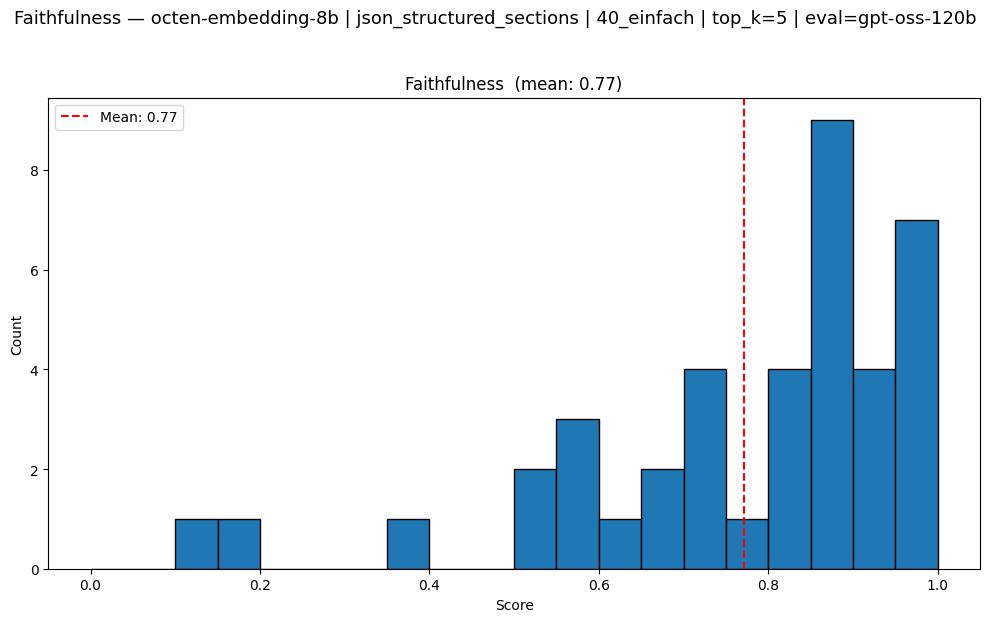

In [12]:
# Histogramm der Faithfulness score
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(faith_df['faithfulness'], bins=20, edgecolor='black', range=(0,1))
ax.set_xlabel('Score')
ax.set_ylabel('Count')
mean_score = faith_df['faithfulness'].mean()
ax.set_title(f'Faithfulness  (mean: {mean_score:.2})')
ax.axvline(mean_score, color='red', linestyle='--', label=f'Mean: {mean_score:.2f}')
ax.legend()

fig.suptitle(
    f'Faithfulness — {EMBED_SHORT} | {CHUNKING_MODE} | {DATASET} | top_k={TOP_K} | eval={EVALUATOR_SHORT}',
    fontsize=13, y=1.03,
)
plt.tight_layout()

# Figur speichern
fig_dir = FIGURES_DIR / '04_generation_evaluation'
fig_dir.mkdir(parents=True, exist_ok=True)
fig_path = fig_dir / f'faithfulness_hist__{EMBED_SHORT}__{CHUNKING_MODE}__{DATASET}__top{TOP_K}__{EVALUATOR_SHORT}.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved: {fig_path}')

plt.show()

In [13]:
# Beste und schlechteste Frage (Faithfulness) vergleichen
for label, row in [('Schlechteste', faith_df.nsmallest(1, 'faithfulness').iloc[0]),
                    ('Beste', faith_df.nlargest(1, 'faithfulness').iloc[0])]:
    print(f'=== {label} Frage (Score: {row["faithfulness"]:.3f}) ===')
    print(f'Frage: {row["user_input"]}\n')
    display(Markdown(f'**Referenzantwort:**\n\n{row["reference"]}'))
    display(Markdown(f'**Generierte Antwort:**\n\n{row["response"]}'))
    print()

=== Schlechteste Frage (Score: 0.119) ===
Frage: Wie ist Outsourcing im Notfallmanagement zu berücksichtigen?



**Referenzantwort:**

Ein Notfallkonzept sollte in der Organisation vorhanden sein und auf einer Business-Impact-Analyse basieren. Es muss die Abhängigkeiten zwischen ausgelagerten und internen Prozessen berücksichtigen. Dienstleister sollten in das Notfallkonzept einbezogen und abgestimmt werden. Verantwortliche für die Schnittstellen zu den Dienstleistern sollten benannt sein, um im Notfall Informationen auszutauschen und effektiv zusammenzuarbeiten. Für Störungen oder Ausfälle der Dienstleister sollten gemeinsame Notfall- und Krisenpläne erstellt werden, und standardisierte Protokolle für die Meldung von Sicherheitsvorfällen sollten genutzt werden.

**Generierte Antwort:**

**Outsourcing muss im Notfallmanagement systematisch berücksichtigt werden.**  

Die bereitgestellten Quellen geben folgende Vorgaben (alle mit *soll* bzw. *muss* gekennzeichnet):

1. **Einbindung in das Notfallkonzept**  
   * Das Notfallkonzept der Institution muss erstellt werden (OPS.3.2.A11) und dabei **die ausgelagerten Prozesse sowie die zugehörigen Sub‑Dienstleister** berücksichtigen.  
   * Es muss auf einer **Business‑Impact‑Analyse** basieren, die die **Abhängigkeiten zwischen internen und ausgelagerten Prozessen** aufzeigt (OPS.2.3.A20).

2. **Benennung von Verantwortlichen und Schnittstellen**  
   * Für jede Schnittstelle zu einem Outsourcing‑Anbieter sind **verantwortliche Personen zu benennen und zu besetzen** (OPS.2.3.A20).  
   * Diese Verantwortlichen sorgen für **Informationsaustausch und effektive Kollaboration** im Not‑ oder Krisenfall.

3. **Gemeinsame Not‑ und Krisenfallpläne**  
   * Es sollen **gemeinsame Not‑ und Krisenfallpläne** für Störungen oder Ausfälle von Outsourcing‑Anbietern erstellt werden (OPS.2.3.A20).  
   * **Standardisierte Protokolle und Berichte** für die Meldung von Sicherheitsvorfällen sind zu etablieren.

4. **Vertragliche Regelungen und regelmäßige Prüfung**  
   * In den Verträgen muss die **Notfallvorsorge‑ und Notfallreaktionsplanung** des Liefer‑ bzw. Dienstleistungs‑Anbieters regelmäßig geprüft werden (DER.4.A16).  
   * Die **Abläufe von Notfalltests und -übungen** sind mit dem Anbieter abzustimmen und – wenn sinnvoll – gemeinsam durchzuführen.  

5. **Ergebnis‑ und Verbesserungsmanagement**  
   * Die **Ergebnisse und Auswertungen** von Tests/Übungen müssen zwischen der Institutionsleitung und dem Outsourcing‑Partner ausgetauscht werden (DER.4.A16).  
   * Aus den Auswertungen sind **Verbesserungsmaßnahmen** abzuleiten und umzusetzen.

6. **Risiko‑ und Kaskadeneffekte**  
   * Ohne ausreichende Notfallvorsorge kann ein Ausfall des Outsourcing‑Anbieters zu **Kaskadeneffekten** führen, die nicht nur die eigene Institution, sondern auch vorgelagerte und nachgelagerte Dienstleister sowie Kunden beeinträchtigen (Quelle 1, 2, 3).  

### Zusammengefasst

- **Outsourcing‑Anbieter** werden als integraler Bestandteil des Notfallmanagements behandelt.  
- Das **Notfallkonzept** muss deren Prozesse, Abhängigkeiten und Schnittstellen explizit berücksichtigen.  
- **Verantwortliche** für die Schnittstellen werden benannt, und es werden **gemeinsame Not‑/Krisenpläne** sowie standardisierte Meldungsprotokolle erstellt.  
- **Vertraglich** ist die regelmäßige Prüfung des Notfallmanagements des Anbieters sowie die Abstimmung und Durchführung gemeinsamer Tests festzuhalten.  
- **Ergebnisse** werden ausgetauscht und führen zu kontinuierlichen Verbesserungen, um Kaskadeneffekte zu vermeiden.  

Nur wenn diese Punkte umgesetzt werden, kann eine **effektive Notfallbewältigung** trotz ausgelagerter Komponenten sichergestellt sein.


=== Beste Frage (Score: 1.000) ===
Frage: Wer trägt die Verantwortung für Informationssicherheit beim Outsourcing?



**Referenzantwort:**

Die Verantwortung für Informationssicherheit verbleibt vollständig bei der auslagernden Institution.

**Generierte Antwort:**

Die Verantwortung für die Informationssicherheit liegt beim **auslagernden Unternehmen bzw. bei der Institution, die das Outsourcing in Anspruch nimmt**.  

Obwohl die anbietenden Dienstleister vertraglich verpflichtet sind, ein bestimmtes Sicherheitsniveau einzuhalten, bleibt die letztendliche Verantwortung aus Sicht der Informationssicherheit stets bei der auslagernden Institution. Diese muss sicherstellen, dass die geforderten Schutzziele (Vertraulichkeit, Integrität, Verfügbarkeit) und alle regulatorischen Vorgaben im Outsourcing‑Prozess erfüllt werden.

## 5) Experiment: System-Prompt verändern

Was passiert mit der Faithfulness, wenn wir dem LLM **erlauben**, über den Kontext hinaus zu antworten?

Wir ersetzen den restriktiven System-Prompt durch einen, der das Modell ermutigt,
zusätzliches Wissen einzubringen — und messen, wie stark die Faithfulness sinkt.

> **Erwartet:** Der Faithfulness-Score sollte deutlich fallen, da das LLM
> nun Aussagen generiert, die nicht im Kontext belegt sind.

In [14]:
# Alternativer System-Prompt: ermutigt das LLM, Antworten möglichst kurz zu beantworten, ohne relevante Informationen zu verlieren.
system_prompt_short = (
    'Du bist ein RAG-Assistent für IT-Grundschutz. '
    'Beantworte die Frage nur auf Basis des bereitgestellten Kontexts. '
    'Wenn die Information im Kontext nicht enthalten ist, sage das klar.'
    'Beantworte die Frage in kurzen Sätzen. '
    'Wenn möglich, beantworte die Frage in maximal 1 bis 5 Sätzen. '
    'Je kürzer und klarer deine Antwort ist, desto besser. '
    'Gib nur Informationen an, die relevant für die Frage sind. '
)

# Alternativer System-Prompt: ermutigt das LLM, über den Kontext hinauszugehen
system_prompt_hallucination = (
    'Du bist ein Experte für IT-Sicherheit und IT-Grundschutz. '
    'Beantworte die Frage ausführlich und umfassend. '
    'Nutze den bereitgestellten Kontext als Ausgangspunkt, aber ergänze '
    'dein Expertenwissen, um eine möglichst vollständige Antwort zu geben. '
    'Nenne auch Best Practices und Empfehlungen, die über den Kontext hinausgehen.'
)

# ------------------- YOUR TASK BELOW ---------------------
# Versuchen Sie den system prompt zu verändern. Schaffen Sie es, bessere Scores zu erreichen? 
# Welcher prompt hilft, welcher verschlechtert die Werte?
# Warum?

# Your custom prompt
YOUR_PROMPT = ('...')

# Choose the modified system prompt (system_prompt_short, system_prompt_hallucination or your custom prompt)
SYSTEM_PROMPT_MODIFIED = system_prompt_short
# ------------------- YOUR TASK ABOVE ---------------------

# Nur die ersten N_EXPERIMENT Fragen für das Experiment, da es sonst zu lange dauert
N_EXPERIMENT = 1

# --- Schritt 1: Antworten mit alternativem Prompt parallel generieren ---
print(f'Generiere Antworten mit alternativem Prompt ({N_EXPERIMENT} Fragen, parallel)...')
experiment_responses = list(await asyncio.gather(*[
    generate_rag_answer(q, ctxs, system_prompt=SYSTEM_PROMPT_MODIFIED)
    for q, ctxs in zip(questions[:N_EXPERIMENT], retrieved_contexts[:N_EXPERIMENT])
]))
print(f'Fertig.\n')

# --- Schritt 2: Answer Correctness evaluieren ---
print(f'Evaluiere Answer Correctness ({N_EXPERIMENT} Fragen)...')
ac_experiment_inputs = [
    {
        'user_input': questions[i],
        'response': experiment_responses[i],
        'reference': references[i],
    }
    for i in range(N_EXPERIMENT)
]
ac_experiment_results = await answer_correctness.abatch_score(ac_experiment_inputs)
ac_experiment_scores = [float(r.value) for r in ac_experiment_results]

# answer correctness scores vom ursprünglichen system_prompt
ac_subset = ac_scores[:N_EXPERIMENT]
ac_subset_avg = sum(ac_subset) / len(ac_subset)
ac_experiment_avg = sum(ac_experiment_scores) / len(ac_experiment_scores)

print(f'  Answer Correctness (Original-Prompt, erste {N_EXPERIMENT}):  {ac_subset_avg:.2f}')
print(f'  Answer Correctness (Modifizierter Prompt, erste {N_EXPERIMENT}): {ac_experiment_avg:.2f}')
print(f'  Differenz:                                       {ac_experiment_avg - ac_subset_avg:+.2f}')
print()

# --- Schritt 3: Faithfulness evaluieren ---
print(f'Evaluiere Faithfulness ({N_EXPERIMENT} Fragen)...')
faith_experiment_inputs = [
    {
        'user_input': questions[i],
        'response': experiment_responses[i],
        'retrieved_contexts': retrieved_contexts[i],
    }
    for i in range(N_EXPERIMENT)
]
faith_experiment_results = await faithfulness.abatch_score(faith_experiment_inputs)
faith_experiment_scores = [float(r.value) for r in faith_experiment_results]

# faithfullness scores vom ursprünglichen system_prompt
faith_subset = faith_scores[:N_EXPERIMENT]
faith_subset_avg = sum(faith_subset) / len(faith_subset)
faith_experiment_avg = sum(faith_experiment_scores) / len(faith_experiment_scores)

print(f'  Faithfulness (Original-Prompt, erste {N_EXPERIMENT}):  {faith_subset_avg:.2f}')
print(f'  Faithfulness (Modifizierter Prompt, erste {N_EXPERIMENT}): {faith_experiment_avg:.2f}')
print(f'  Differenz:                                  {faith_experiment_avg - faith_subset_avg:+.2f}')
print()

# --- Zusammenfassung ---
print('=' * 80)
print(f'{"Metrik":<25} {"Original":>10} {"Modifiziert":>12} {"Differenz":>10}')
print('-' * 80)
print(f'{"Answer Correctness":<25} {ac_subset_avg:>10.2f} {ac_experiment_avg:>12.2f} {ac_experiment_avg - ac_subset_avg:>+10.2f}')
print(f'{"Faithfulness":<25} {faith_subset_avg:>10.2f} {faith_experiment_avg:>12.2f} {faith_experiment_avg - faith_subset_avg:>+10.2f}')
print('=' * 80)

Generiere Antworten mit alternativem Prompt (1 Fragen, parallel)...
Fertig.

Evaluiere Answer Correctness (1 Fragen)...
  Answer Correctness (Original-Prompt, erste 1):  0.53
  Answer Correctness (Modifizierter Prompt, erste 1): 0.68
  Differenz:                                       +0.15

Evaluiere Faithfulness (1 Fragen)...
  Faithfulness (Original-Prompt, erste 1):  0.92
  Faithfulness (Modifizierter Prompt, erste 1): 0.57
  Differenz:                                  -0.35

Metrik                      Original  Modifiziert  Differenz
--------------------------------------------------------------------------------
Answer Correctness              0.53         0.68      +0.15
Faithfulness                    0.92         0.57      -0.35


In [15]:
# Erste Frage des Experiments im Detail anzeigen
i = 0
print(f'Frage: {questions[i]}\n')
print(f'Answer Correctness: Original={ac_scores[i]:.2f}  |  Experiment={ac_experiment_scores[i]:.2f}')
print(f'Faithfulness:       Original={faith_scores[i]:.2f}  |  Experiment={faith_experiment_scores[i]:.2f}')
print()
display(Markdown(f'**Referenzantwort:**\n\n{references[i]}'))
print('—' * 80)
display(Markdown(f'**Antwort (Original-Prompt):**\n\n{responses[i]}'))
print('—' * 80)
display(Markdown(f'**Antwort (Modifizierter Prompt):**\n\n{experiment_responses[i]}'))


Frage: Was ist der Unterschied zwischen Prozess- und Systembausteinen?

Answer Correctness: Original=0.53  |  Experiment=0.68
Faithfulness:       Original=0.92  |  Experiment=0.57



**Referenzantwort:**

Prozess-Bausteine gelten in der Regel für sämtliche oder große Teile des Informationsverbunds gleichermaßen, System-Bausteine lassen sich in der Regel auf einzelne Objekte oder Gruppen von Objekten anwenden. Die Prozess- und System-Bausteine bestehen wiederum aus weiteren Teilschichten. In den Hinweisen zum Schichtenmodell und zur Modellierung wird beschrieben, wann ein einzelner Baustein sinnvollerweise eingesetzt werden soll und auf welche Zielobjekte er anzuwenden ist. 

————————————————————————————————————————————————————————————————————————————————


**Antwort (Original-Prompt):**

**Unterschied zwischen Prozess‑ und Systembausteinen**

| Merkmal | Prozess‑Bausteine | System‑Bausteine |
|---------|-------------------|------------------|
| **Anwendungsbereich** | Geltung für **gesamte** oder **große Teile** eines Informationsverbundes. Sie beschreiben Vorgänge, die für den gesamten Betrieb oder für alle bzw. die meisten Komponenten relevant sind. | Geltung für **einzelne Zielobjekte** (z. B. ein Server, ein Netzwerkgerät, eine Anwendung) oder für **Gruppen von Zielobjekten**. Sie beziehen sich auf die konkrete Ausgestaltung eines bestimmten Systems. |
| **Inhalt / Fokus** | Beschreiben **Prozesse** und organisatorische Aspekte des Sicherheitsmanagements: <br>• ISMS (Sicherheitsmanagement) <br>• ORP (Organisation & Personal) <br>• CON (Konzepte & Vorgehensweisen) <br>• OPS (operative IT‑Betriebsaspekte) <br>• DER (Detektion, Reaktion, Forensik) | Beschreiben **technische bzw. systembezogene** Sicherheitsanforderungen und Maßnahmen, die auf ein konkretes IT‑System oder eine Systemgruppe angewendet werden (z. B. Server‑Hardening, Router‑Konfiguration, Anwendungssicherheit). |
| **Struktur** | Wie die System‑Bausteine sind auch die Prozess‑Bausteine in **Schichten** (ISMS, ORP, CON, OPS, DER) und können weitere **Teilschichten** enthalten. | Ebenfalls in **Schichten** unterteilt, die analog zu den Prozess‑Bausteinen aufgebaut sein können, jedoch jeweils auf ein konkretes Zielobjekt ausgerichtet sind. |
| **Ziel** | Schaffung eines übergreifenden **Sicherheitsrahmens** und Definition von **organisatorischen, konzeptionellen und betrieblichen** Vorgaben, die im gesamten Verbund einheitlich umgesetzt werden. | Umsetzung von **spezifischen Sicherheitsmaßnahmen** für ein bestimmtes System bzw. eine Systemgruppe, um die dortigen Risiken zu adressieren. |
| **Beispiel** | „Sicherheitsmanagement“, „Organisation“, „Kryptokonzept“, „Schutz vor Schadprogrammen“, „Behandlung von Sicherheitsvorfällen“. | Ein Baustein für einen Windows‑Server, ein Baustein für ein Datenbanksystem, ein Baustein für ein Netzwerk‑Switch‑Modell usw. (im Kontext nur allgemein als „System‑Bausteine“ bezeichnet). |

**Zusammengefasst:**  
Prozess‑Bausteine definieren **übergreifende, prozess- und organisationsbezogene** Sicherheitsanforderungen, die für den gesamten Informationsverbund gelten. System‑Bausteine hingegen spezifizieren **system‑ oder objektbezogene** Sicherheitsmaßnahmen, die auf einzelne Geräte, Anwendungen oder Gruppen von Objekten angewendet werden. Beide Bausteintypen sind im IT‑Grundschutz‑Kompendium modular aufgebaut und in Schichten strukturiert, dienen jedoch unterschiedlichen Ebenen der Sicherheitsmodellierung.

————————————————————————————————————————————————————————————————————————————————


**Antwort (Modifizierter Prompt):**

Prozess‑Bausteine beschreiben Aktivitäten, Konzepte und organisatorische Vorgaben, die für den gesamten Informationsverbund oder für große Teile davon gelten (z. B. Sicherheits‑Management, Organisation, Kryptokonzept, Betrieb, Incident‑Handling).  
System‑Bausteine dagegen beziehen sich auf konkrete Zielobjekte oder Objektgruppen – also auf einzelne IT‑Komponenten oder Systeme – und werden jeweils für diese spezifisch umgesetzt.  

Kurz: Prozess‑Bausteine gelten allgemein für den Verbund, System‑Bausteine gelten für einzelne Systeme bzw. Objektgruppen.

## Diskussion

- Wie beeinflusst die Länge einer Antwort Answer Correctness und Faithfulness?
- Wie unterscheiden sich Answer Correctness und Faithfulness? Bei welchen Fragen divergieren sie?
- Ist mein RAG System gezwungenermaßen "schlecht" wenn mein Answer Correctness Score niedrig ist?
- Bei welchen Antworten ist die Faithfulness besonders niedrig? 
- Ist der Faithfulness-Score mit dem offenen Prompt gefallen? Ist das Ergebnis intuitiv?
- Kann ein RAG-System trotz guter Kontexte (hohe Context Precision) schlecht antworten?